In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import linkage, dendrogram


In [ ]:
df = pd.read_csv('/content/single_genre_artists.csv')

print(df.head(5))

                 id_songs         name_song  popularity_songs  duration_ms  \
0  0IA0Hju8CAgYfV1hwhidBH           La Java                 0       161427   
1  1b8HZQCqcqwbzlA1jRTp6E          En Douce                 0       223440   
2  5d5gQxHwYovxR5pqETOIAa     J'en Ai Marre                 0       208267   
3  1EO65UEEPfy7CR0NK2sDxy  Ils n'ont pas ca                 0       161933   
4  6a58gXSgqbIsXUhVZ6ZJqe         La belote                 0       167973   

   explicit              id_artists release_date  danceability  energy  key  \
0         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.563   0.184    4   
1         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.427   0.180   10   
2         0  4AxgXfD7ISvJSTObqm4aIE         1922         0.511   0.206    0   
3         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.676   0.467    9   
4         0  4AxgXfD7ISvJSTObqm4aIE         1924         0.650   0.298    9   

   ...  acousticness  instrumentalness  liveness  valenc

In [ ]:
#data cleaning
df.shape
df.columns

Index(['id_songs', 'name_song', 'popularity_songs', 'duration_ms', 'explicit',
       'id_artists', 'release_date', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'time_signature', 'followers', 'genres',
       'name_artists', 'popularity_artists'],
      dtype='object')

In [ ]:
df.head()

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0,161427,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4,...,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],Mistinguett,22
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0,223440,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10,...,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],Mistinguett,22
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0,208267,0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0,...,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],Mistinguett,22
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0,161933,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9,...,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],Mistinguett,22
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0,167973,0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9,...,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],Mistinguett,22


In [ ]:
df.dtypes

,0
id_songs,object
name_song,object
popularity_songs,int64
duration_ms,int64
explicit,int64
id_artists,object
release_date,object
danceability,float64
energy,float64
key,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95837 entries, 0 to 95836
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_songs            95837 non-null  object 
 1   name_song           95837 non-null  object 
 2   popularity_songs    95837 non-null  int64  
 3   duration_ms         95837 non-null  int64  
 4   explicit            95837 non-null  int64  
 5   id_artists          95837 non-null  object 
 6   release_date        95837 non-null  object 
 7   danceability        95837 non-null  float64
 8   energy              95837 non-null  float64
 9   key                 95837 non-null  int64  
 10  loudness            95837 non-null  float64
 11  mode                95837 non-null  int64  
 12  speechiness         95837 non-null  float64
 13  acousticness        95837 non-null  float64
 14  instrumentalness    95837 non-null  float64
 15  liveness            95837 non-null  float64
 16  vale

In [ ]:
df.isnull().sum()

,0
id_songs,0
name_song,0
popularity_songs,0
duration_ms,0
explicit,0
id_artists,0
release_date,0
danceability,0
energy,0
key,0


In [ ]:
df[df.isna().any(axis=1)]

,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists


In [ ]:
df = df.drop(index=35938)#90% values missing so we drop this row

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['year'] = df['release_date'].dt.year

In [ ]:
df.describe()

,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists,year
count,95836.000000,9.583600e+04,95836.000000,21494,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,95836.000000,9.583600e+04,95836.000000,21494.000000
mean,26.066301,2.087330e+05,0.029644,1979-02-09 11:20:56.499488256,0.586853,0.541084,5.196753,-10.157839,0.648065,0.168834,0.458987,0.082146,0.224918,0.574277,117.540088,3.851361,1.979938e+05,42.819410,1979.107751
min,0.000000,6.373000e+03,0.000000,1922-01-01 00:00:00,0.000000,0.000020,0.000000,-50.174000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1922.000000
25%,13.000000,1.573330e+05,0.000000,1967-01-01 00:00:00,0.488000,0.365000,2.000000,-12.723000,0.000000,0.034100,0.133000,0.000000,0.100000,0.378000,94.828250,4.000000,2.563000e+03,28.000000,1967.000000
50%,26.000000,2.040000e+05,0.000000,1983-01-01 00:00:00,0.605000,0.542000,5.000000,-9.396500,1.000000,0.046200,0.453000,0.000004,0.149000,0.589000,116.595000,4.000000,1.595550e+04,40.000000,1983.000000
75%,37.000000,2.502670e+05,0.000000,1995-01-01 00:00:00,0.700000,0.727000,8.000000,-6.691750,1.000000,0.103000,0.759000,0.001300,0.302000,0.780000,135.975000,4.000000,8.495100e+04,56.000000,1995.000000
max,98.000000,4.800118e+06,1.000000,2019-01-01 00:00:00,0.991000,1.000000,11.000000,5.376000,1.000000,0.968000,0.996000,1.000000,0.997000,1.000000,239.906000,5.000000,2.802643e+07,95.000000,2019.000000
std,16.254192,1.177528e+05,0.169605,NaN,0.155422,0.236305,3.534930,4.748818,0.477576,0.275418,0.330418,0.232441,0.185829,0.248124,30.190481,0.544408,7.807558e+05,20.897927,21.553395


In [ ]:
for col in df.columns:
    print(col, ":", df[col].unique())

id_songs : ['0IA0Hju8CAgYfV1hwhidBH' '1b8HZQCqcqwbzlA1jRTp6E'
 '5d5gQxHwYovxR5pqETOIAa' ... '1dKxf4Ht2SsKLyXfSDJAgy'
 '0SjsIzJkZfDU7wlcdklEFR' '5rgu12WBIHQtvej2MdHSH0']
name_song : ['La Java' 'En Douce' "J'en Ai Marre" ... 'The Cutest Puppy'
 "John Brown's Song" '云与海']
popularity_songs : [ 0  1 28  4  2 18 14  9  8  6  5 16 10 11  7  3 23 22 12 19 15 13 38 27
 24 45 35 21 46 39 37 36 32 29 25 20 55 47 43 40 33 31 30 17 26 60 53 48
 51 42 52 58 34 44 63 59 50 54 41 56 49 62 65 57 61 70 73 72 64 76 67 68
 66 71 77 69 78 75 79 74 83 81 80 86 84 82 89 91 88 94 92 87 85 98]
duration_ms : [161427 223440 208267 ... 276342 265846 185250]
explicit : [0 1]
id_artists : ['4AxgXfD7ISvJSTObqm4aIE' '7DIlOK9L8d0IQ7Xk8aJxDW'
 '28pbIiOohRRZjqpAM9iqYM' ... '7vgGpuiXdNlCmc994PlMlz'
 '4MxqhahGRT4BPz1PilXGeu' '1QLBXKM5GCpyQQSVMNZqrZ']
release_date : <DatetimeArray>
['1922-01-01 00:00:00', '1924-01-01 00:00:00', '1925-01-01 00:00:00',
 '1926-01-01 00:00:00', '1927-01-01 00:00:00', '1928-01-01 00:00:00',
 '1

In [ ]:
df.drop(columns=['id_songs', 'name_song', 'id_artists', 'name_artists'], inplace=True)

In [ ]:
df.head(5)

,popularity_songs,duration_ms,explicit,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,popularity_artists,year
0,0,161427,0,1922-01-01,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,['vintage chanson'],22,1922.0
1,0,223440,0,1922-01-01,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,['vintage chanson'],22,1922.0
2,0,208267,0,1922-01-01,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,['vintage chanson'],22,1922.0
3,0,161933,0,1924-01-01,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,['vintage chanson'],22,1924.0
4,0,167973,0,1924-01-01,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,['vintage chanson'],22,1924.0


In [ ]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [ ]:
df['year'].isnull().sum()

np.int64(74342)

In [ ]:
df["year"].isna()

,year
0,False
1,False
2,False
3,False
4,False
...,...
95832,True
95833,True
95834,True
95835,True


In [ ]:
df['year'] = df['year'].fillna(df['year'].median())

In [ ]:
# Drop original date because i have year colum
df = df.drop(columns=['release_date'])

In [ ]:
df = df.drop(columns=['genres'])  #too many unique value

In [ ]:
df_clean = df.head()
df_clean


,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists,year
0,0,161427,0,0.563,0.184,4,-13.757,1,0.0512,0.993,0.000016,0.325,0.654,133.088,3,5078.0,22,1922.0
1,0,223440,0,0.427,0.180,10,-15.375,1,0.0670,0.989,0.000000,0.128,0.431,78.459,3,5078.0,22,1922.0
2,0,208267,0,0.511,0.206,0,-15.514,1,0.0592,0.995,0.000000,0.418,0.481,70.443,4,5078.0,22,1922.0
3,0,161933,0,0.676,0.467,9,-12.393,0,0.1650,0.991,0.000000,0.219,0.726,129.775,4,5078.0,22,1924.0
4,0,167973,0,0.650,0.298,9,-13.806,1,0.1380,0.991,0.000000,0.373,0.844,75.950,4,5078.0,22,1924.0


In [ ]:
num_cont = [
    'duration_ms',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'followers'
]

In [ ]:
num_discrete = [
    'popularity_songs',
    'explicit',
    'key',
    'mode',
    'time_signature',
    'popularity_artists',
    'year'
]

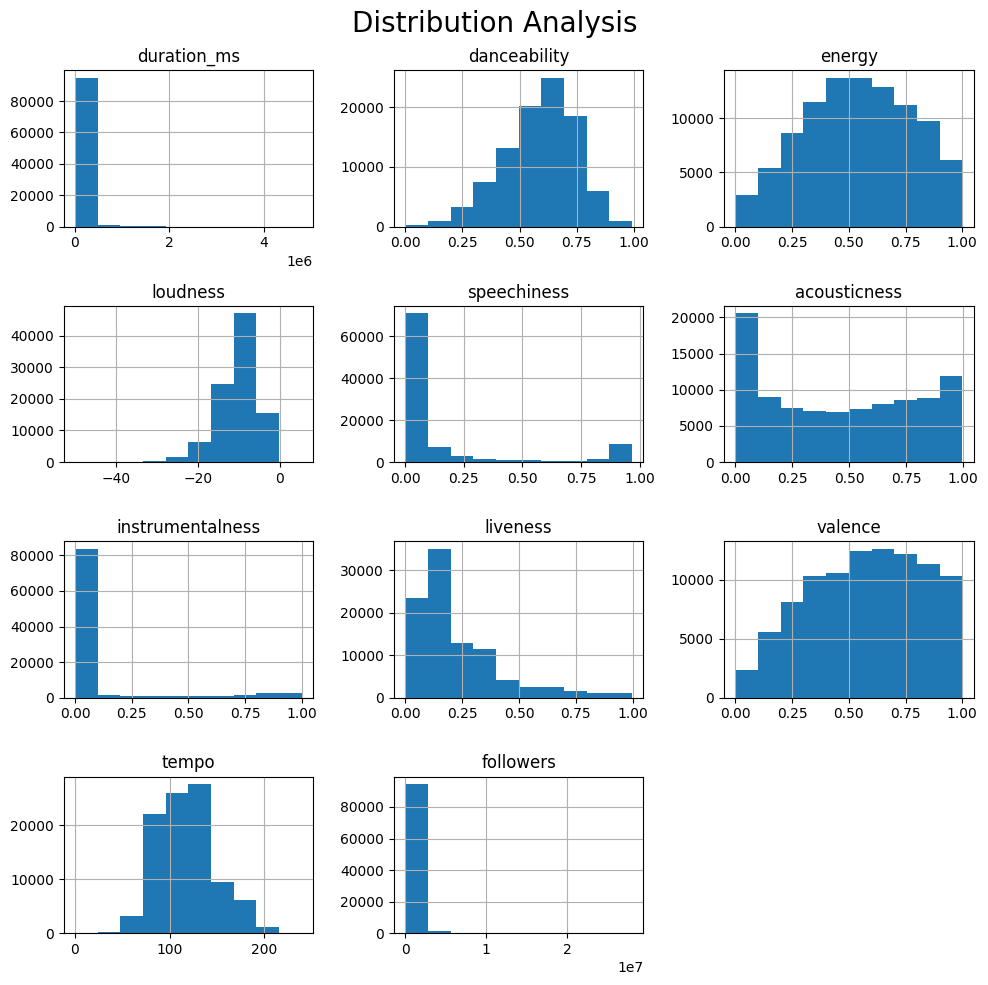

In [ ]:
#EDA (distribution analysis)
df[num_cont].hist(figsize=(10, 10))
title = 'Distribution Analysis'
plt.suptitle(title, fontsize=20)
plt.tight_layout()
plt.show()


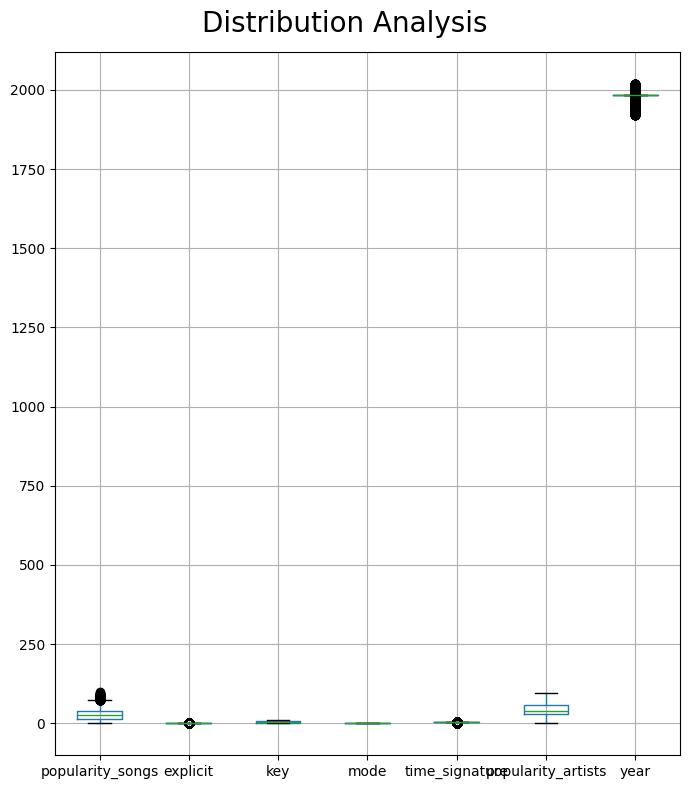

In [ ]:
df[num_discrete].boxplot(figsize=(7,8))
title = 'Distribution Analysis'
plt.suptitle(title, fontsize=20)
plt.tight_layout()

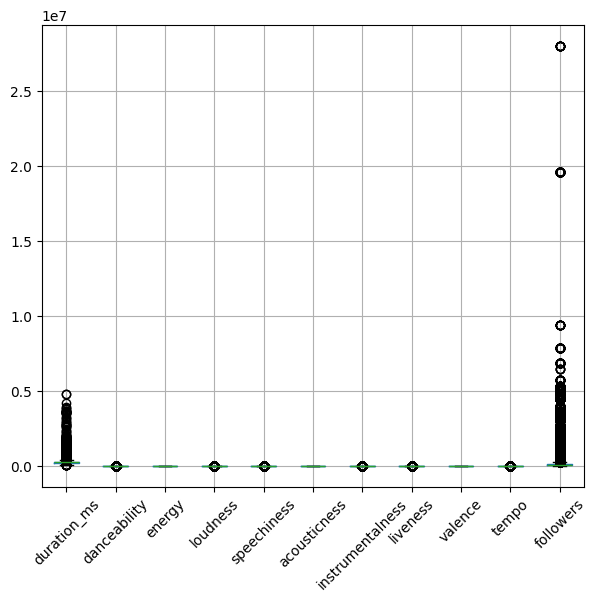

In [ ]:
plt.figure(figsize=(7,6))
df[num_cont].boxplot()
plt.xticks(rotation=45)
plt.show()

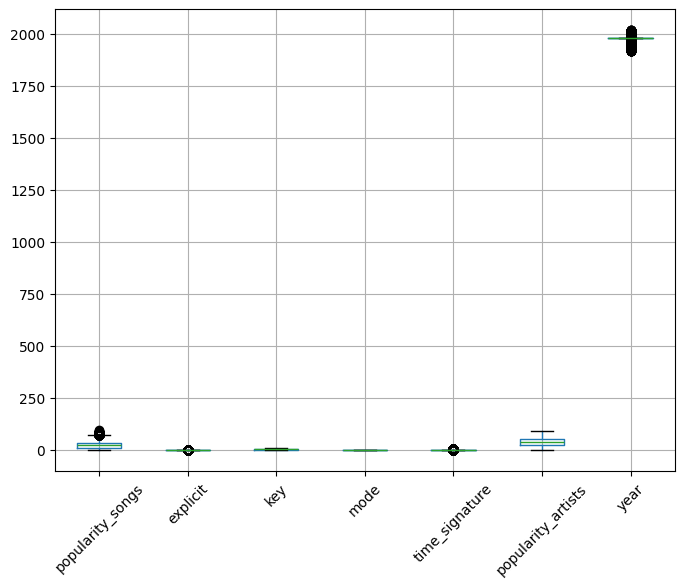

In [ ]:
plt.figure(figsize=(8,6))
df[num_discrete].boxplot()
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Univariate Analysis
Num_cols = df_clean.select_dtypes(include=np.number).columns
Num_cols,

(Index(['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy',
        'key', 'loudness', 'mode', 'speechiness', 'acousticness',
        'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
        'followers', 'popularity_artists', 'year'],
       dtype='object'),)

In [ ]:
df.columns#Normalize the data: scalling

Index(['popularity_songs', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'followers', 'popularity_artists', 'year'],
      dtype='object')

In [ ]:
features = [
    'danceability','energy','loudness',
    'acousticness','instrumentalness',
    'valence','tempo'
]

In [ ]:
import numpy as np

# Calculate quantiles only for numeric columns to avoid string errors
Q1 = df.quantile(0.25, numeric_only=True)
Q3 = df.quantile(0.75, numeric_only=True)
IQR = Q3 - Q1

# Filter outliers only using numeric columns
df_numeric = df.select_dtypes(include=[np.number])
df_clean = df[~((df_numeric < (Q1 - 1.5 * IQR)) | (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
IQR # identify the outlayers

,0
popularity_songs,24.00000
duration_ms,92934.00000
explicit,0.00000
danceability,0.21200
energy,0.36200
key,6.00000
loudness,6.03125
mode,1.00000
speechiness,0.06890
acousticness,0.62600


In [ ]:
df[features]

,danceability,energy,loudness,acousticness,instrumentalness,valence,tempo
0,0.563,0.1840,-13.757,0.993,0.000016,0.654,133.088
1,0.427,0.1800,-15.375,0.989,0.000000,0.431,78.459
2,0.511,0.2060,-15.514,0.995,0.000000,0.481,70.443
3,0.676,0.4670,-12.393,0.991,0.000000,0.726,129.775
4,0.650,0.2980,-13.806,0.991,0.000000,0.844,75.950
...,...,...,...,...,...,...,...
95832,0.674,0.5680,-6.356,0.116,0.000000,0.640,166.107
95833,0.528,0.6730,-3.639,0.143,0.000000,0.297,130.066
95834,0.609,0.0172,-28.573,0.996,0.973000,0.890,68.619
95835,0.562,0.0331,-25.551,0.996,0.961000,0.386,63.696


In [ ]:
df_clean['danceability'].min()


0.171

In [ ]:
df_clean['danceability'].max()

0.984

In [ ]:
SC=StandardScaler()
X_Scaled=SC.fit_transform(df[features])
X_Scaled

array([[-0.15347057, -1.51112344, -0.75791075, ..., -0.3533403 ,
         0.32130501,  0.51499653],
       [-1.02850941, -1.52805082, -1.09862892, ..., -0.35340699,
        -0.57744327, -1.29449055],
       [-0.48804424, -1.41802284, -1.12789951, ..., -0.35340699,
        -0.3759302 , -1.56000609],
       ...,
       [ 0.14249844, -2.21699524, -3.87786152, ...,  3.83262687,
         1.27244669, -1.6204228 ],
       [-0.15990468, -2.1497089 , -3.24148927, ...,  3.78100055,
        -0.75880503, -1.78348829],
       [-0.1727729 , -0.09768709,  0.56579406, ..., -0.35340699,
        -1.46410076,  0.47551368]])

In [ ]:
pd.DataFrame(X_Scaled,columns=features)

,danceability,energy,loudness,acousticness,instrumentalness,valence,tempo
0,-0.153471,-1.511123,-0.757911,1.616185,-0.353340,0.321305,0.514997
1,-1.028509,-1.528051,-1.098629,1.604079,-0.353407,-0.577443,-1.294491
2,-0.488044,-1.418023,-1.127900,1.622238,-0.353407,-0.375930,-1.560006
3,0.573584,-0.313511,-0.470680,1.610132,-0.353407,0.611484,0.405259
4,0.406297,-1.028693,-0.768229,1.610132,-0.353407,1.087055,-1.377597
...,...,...,...,...,...,...,...
95831,0.560716,0.113905,0.800591,-1.038047,-0.353407,0.264881,1.608691
95832,-0.378664,0.558249,1.372736,-0.956332,-0.353407,-1.117498,0.414898
95833,0.142498,-2.216995,-3.877862,1.625264,3.832627,1.272447,-1.620423
95834,-0.159905,-2.149709,-3.241489,1.625264,3.781001,-0.758805,-1.783488


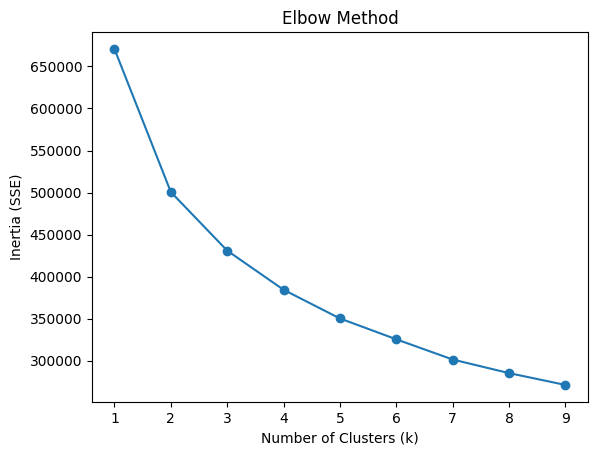

In [ ]:
inertia = []

# Drop rows with NaN values in the features used for clustering before scaling
X_clean = df[features].dropna()
X_Scaled = StandardScaler().fit_transform(X_clean)

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # Added n_init to suppress warning
    kmeans.fit(X_Scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method")
plt.show()

In [ ]:
for k in range(2,3):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_Scaled)
    score = silhouette_score(X_Scaled, labels)
    print(f"k={k}, score={score}")

k=2, score=0.24311323584038386


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
cluster_labels = kmeans.fit_predict(X_Scaled)

# Update df to only contain the rows that were used for clustering
df = df.loc[X_clean.index].copy()

df['cluster'] = cluster_labels

In [ ]:
kmeans.predict(X_Scaled)

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [ ]:
df[['cluster']]

,cluster
0,0
1,0
2,0
3,0
4,0
...,...
95832,1
95833,1
95834,0
95835,0


In [ ]:
df.groupby('cluster')[features].mean()

,danceability,energy,loudness,acousticness,instrumentalness,valence,tempo
cluster,,,,,,,
0,0.529425,0.326254,-13.631941,0.728910,0.130741,0.45154,108.667154
1,0.627004,0.691284,-7.728887,0.270268,0.048170,0.66009,123.743685


In [ ]:
cluster_names = {
    0: "Energetic Party Songs 🎉",
    1: "Calm Acoustic Songs 🎧"
}

df['segment'] = df['cluster'].map(cluster_names)

In [ ]:
df['Predicted_Cluster']=kmeans.predict(X_Scaled)
df

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,...,liveness,valence,tempo,time_signature,followers,popularity_artists,year,cluster,segment,Predicted_Cluster
0,0,161427,0,0.563,0.1840,4,-13.757,1,0.0512,0.993,...,0.3250,0.654,133.088,3,5078.0,22,1922.0,0,Energetic Party Songs 🎉,0
1,0,223440,0,0.427,0.1800,10,-15.375,1,0.0670,0.989,...,0.1280,0.431,78.459,3,5078.0,22,1922.0,0,Energetic Party Songs 🎉,0
2,0,208267,0,0.511,0.2060,0,-15.514,1,0.0592,0.995,...,0.4180,0.481,70.443,4,5078.0,22,1922.0,0,Energetic Party Songs 🎉,0
3,0,161933,0,0.676,0.4670,9,-12.393,0,0.1650,0.991,...,0.2190,0.726,129.775,4,5078.0,22,1924.0,0,Energetic Party Songs 🎉,0
4,0,167973,0,0.650,0.2980,9,-13.806,1,0.1380,0.991,...,0.3730,0.844,75.950,4,5078.0,22,1924.0,0,Energetic Party Songs 🎉,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95832,70,174800,0,0.674,0.5680,1,-6.356,1,0.0408,0.116,...,0.1650,0.640,166.107,4,16057.0,56,1983.0,1,Calm Acoustic Songs 🎧,1
95833,50,265846,0,0.528,0.6730,4,-3.639,1,0.0314,0.143,...,0.0989,0.297,130.066,4,929.0,36,1983.0,1,Calm Acoustic Songs 🎧,1
95834,67,82500,0,0.609,0.0172,8,-28.573,1,0.1180,0.996,...,0.1080,0.890,68.619,4,23.0,52,1983.0,0,Energetic Party Songs 🎉,0
95835,66,185250,0,0.562,0.0331,1,-25.551,1,0.1030,0.996,...,0.1110,0.386,63.696,3,91.0,55,1983.0,0,Energetic Party Songs 🎉,0


In [ ]:
cluster_mean = df.groupby('cluster').mean(numeric_only=True)
print(cluster_mean)

         popularity_songs    duration_ms  explicit  danceability    energy  \
cluster                                                                      
0               21.830781  198802.235431  0.006289      0.529425  0.326254   
1               29.027605  215676.221588  0.045974      0.627004  0.691284   

              key   loudness      mode  speechiness  acousticness  \
cluster                                                             
0        5.125222 -13.631941  0.671907     0.215859      0.728910   
1        5.246764  -7.728887  0.631396     0.135955      0.270268   

         instrumentalness  liveness  valence       tempo  time_signature  \
cluster                                                                    
0                0.130741  0.228986  0.45154  108.667154        3.756352   
1                0.048170  0.222074  0.66009  123.743685        3.917787   

             followers  popularity_artists         year  Predicted_Cluster  
cluster                     

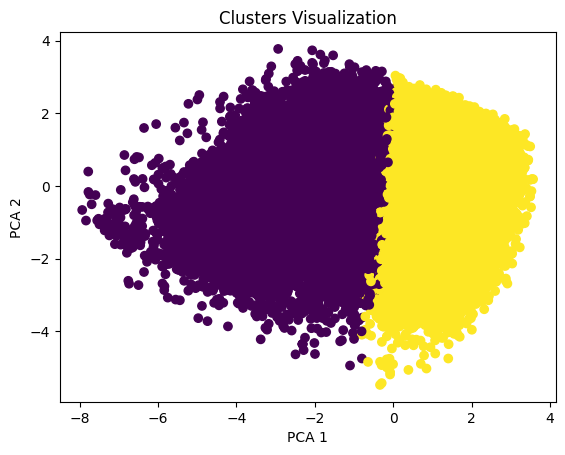

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_Scaled)

# Plot
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Clusters Visualization")

plt.show()

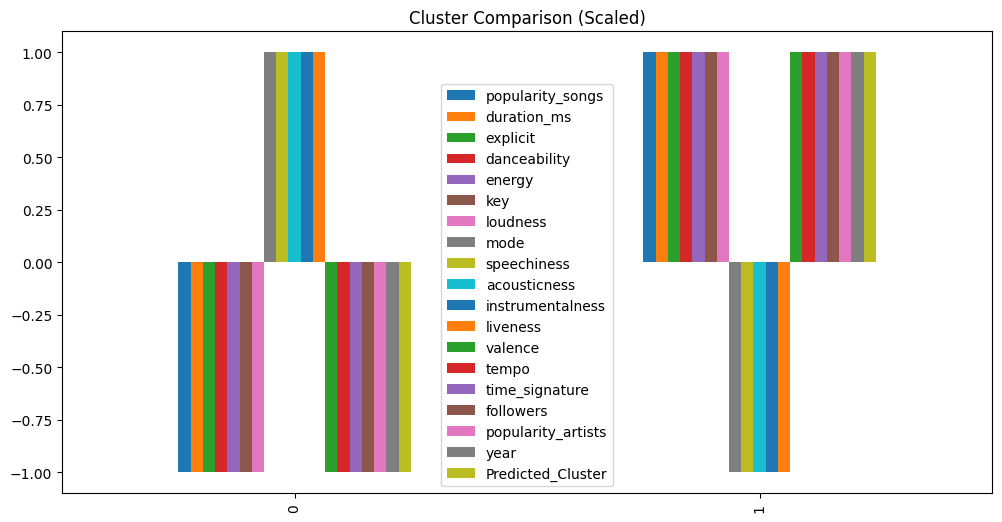

In [ ]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

# Fix: Added numeric_only=True to ignore non-numeric columns during mean calculation
cluster_mean = df.groupby('cluster').mean(numeric_only=True)

scaler = StandardScaler()
scaled_mean = scaler.fit_transform(cluster_mean)

scaled_df = pd.DataFrame(scaled_mean, columns=cluster_mean.columns)

scaled_df.plot(kind='bar', figsize=(12,6))

plt.title("Cluster Comparison (Scaled)")
plt.show()

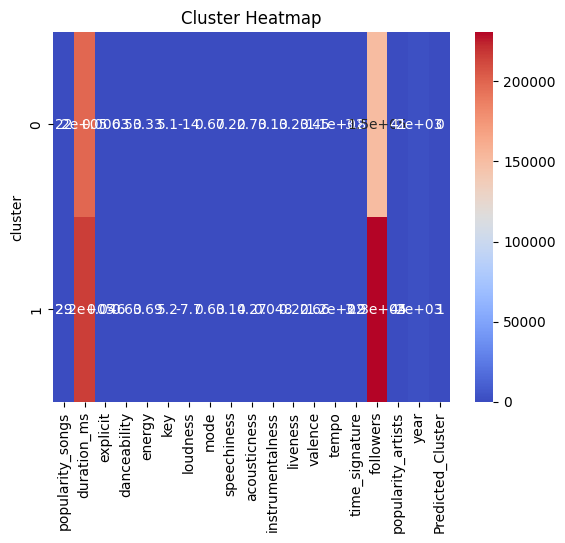

In [ ]:
import seaborn as sns

sns.heatmap(cluster_mean, annot=True, cmap='coolwarm')

plt.title("Cluster Heatmap")
plt.show()

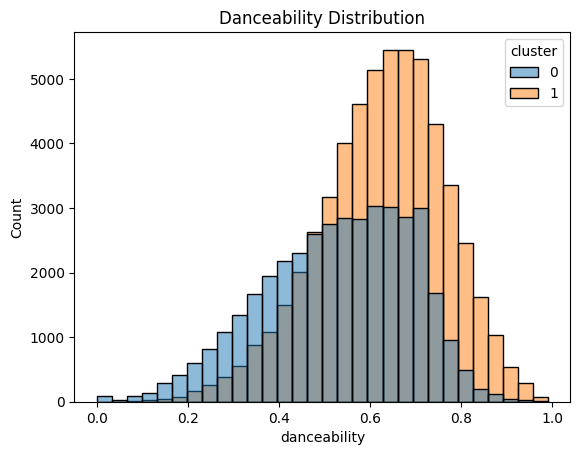

In [ ]:
import seaborn as sns

sns.histplot(data=df, x='danceability', hue='cluster', bins=30)

plt.title("Danceability Distribution")
plt.show()

In [ ]:
from sklearn.manifold import TSNE
import pandas as pd

# Sample data (important)
X_sample = pd.DataFrame(X_Scaled).sample(n=1500, random_state=0)

# Updated TSNE
tsne = TSNE(
    n_components=2,
    max_iter=250,   # updated
    perplexity=30,
    init='random',
    learning_rate='auto',
    random_state=0
)

X_tsne = tsne.fit_transform(X_sample)

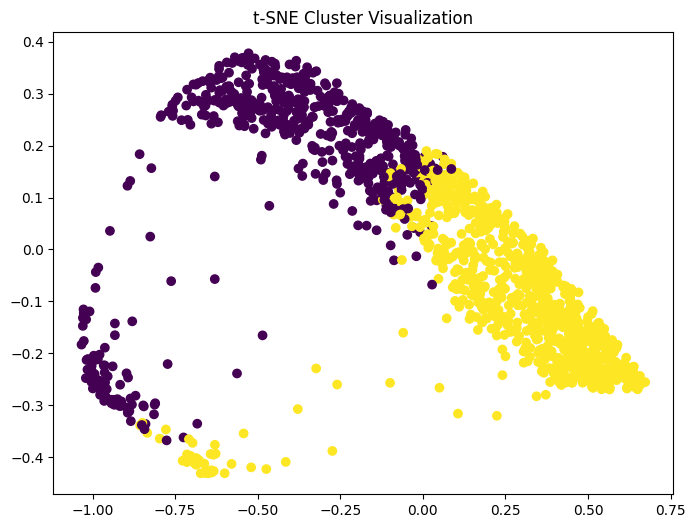

In [ ]:
plt.figure(figsize=(8,6))
sampled_labels = kmeans.predict(X_sample)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=sampled_labels, cmap='viridis')
plt.title("t-SNE Cluster Visualization")
plt.show()# Mostly separated, Slight overlap in middle but that is normal


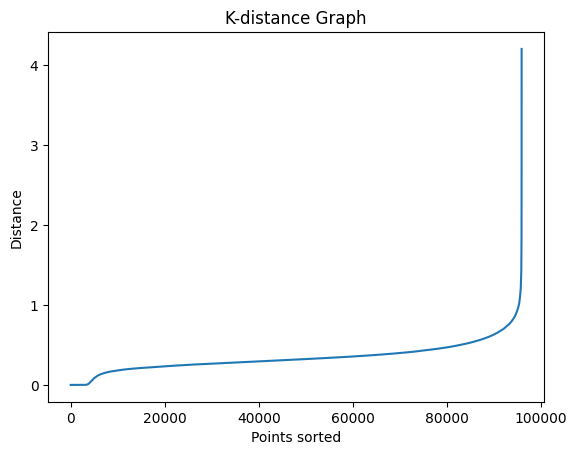

In [ ]:
# Step 2: fit nearest neighbors
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_Scaled)

# Step 3: get distances
distances, indices = neighbors_fit.kneighbors(X_Scaled)

# Step 4: sort distances
distances = np.sort(distances[:, k-1])

# Step 5: plot graph
plt.plot(distances)
plt.title("K-distance Graph")
plt.xlabel("Points sorted")
plt.ylabel("Distance")
plt.show()#ecommended eps = 0.5

In [ ]:
db = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = db.fit_predict(X_Scaled)
df['cluster'].value_counts()

,count
cluster,
0,73019
-1,20778
20,375
87,285
7,63
...,...
161,2
179,2
181,2


### Hierarchical Clustering (Agglomerative)

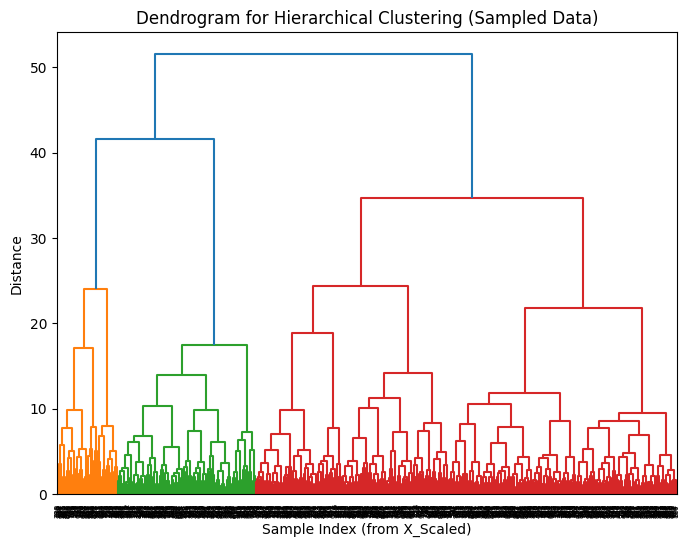

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

# To create a readable dendrogram, we will sample a subset of the scaled data.
X_sample_dendrogram = X_Scaled[np.random.choice(X_Scaled.shape[0], 1000, replace=False)]

# Perform hierarchical clustering
linked = linkage(X_sample_dendrogram, method='ward') # 'ward' minimizes the variance of the clusters being merged.

# Plot the dendrogram
plt.figure(figsize=(8, 6))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram for Hierarchical Clustering (Sampled Data)')
plt.xlabel('Sample Index (from X_Scaled)')
plt.ylabel('Distance')
plt.show()

Final Analysis and Export

In [ ]:
df['cluster'] = labels

In [ ]:
df_sorted = df.sort_values(by='popularity_songs', ascending=False)

top_songs = df_sorted.groupby('cluster').head(5)

print(top_songs[['cluster', 'popularity_songs']])

       cluster  popularity_songs
35665        1                98
35398        1                94
35422        1                92
35241        1                91
35532        1                91
35233        0                89
35436        0                87
34858        0                83
35234        0                83
35463        0                83


In [ ]:
df.to_csv("clustered_songs.csv", index=False)

In [ ]:
!pip install -q streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 97.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 86.6 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import base64
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score

# --- Page Configuration ---
st.set_page_config(page_title="Music Insight Dashboard", layout="wide")
sns.set_theme(style="whitegrid")

def get_base64(bin_file):
    try:
        with open(bin_file, 'rb') as f:
            data = f.read()
        return base64.b64encode(data).decode()
    except:
        return ""

# --- Background Styling ---
# Using the selected background image
img_path = "/content/Black Friday 2025 music unlimited.webp"
bin_str = get_base64(img_path)


# Updated CSS for dark blurred background behind text
page_bg_style = f"""
<style>
/* Main background image */
[data-testid="stAppViewContainer"] {{
    background-image: url("data:image/webp;base64,{bin_str}");
    background-size: cover;
    background-position: center;
    background-attachment: fixed;
}}

/* Enhanced Blur + Dark background behind the main text content */
[data-testid="stVerticalBlock"] > div:has(div.stMarkdown) {{
    background-color: rgba(0, 0, 0, 0.6);
    backdrop-filter: blur(15px);
    -webkit-backdrop-filter: blur(15px);
    padding: 2.5rem;
    border-radius: 20px;
    margin-bottom: 1.5rem;
    color: white;
    border: 1px solid rgba(255, 255, 255, 0.1);
}}

/* Ensure headers and text are readable on dark background */
h1, h2,p, span, label {{
    color: white !important;
}}

/* Sidebar styling */
[data-testid="stSidebar"] {{
    background-image: linear-gradient(rgba(0,0,0,0.7), rgba(0,0,0,0.7)), url("data:image/webp;base64,{bin_str}");
    background-size: cover;
}}

[data-testid="stSidebar"] .stMarkdown, [data-testid="stSidebar"] .stSlider, [data-testid="stSidebar"] .stHeader {{
    background-color: rgba(0, 0, 0, 0.5);
    backdrop-filter: blur(5px);
    padding: 10px;
    border-radius: 10px;
    margin-bottom: 10px;
}}
</style>
"""
st.markdown(page_bg_style, unsafe_allow_html=True)

# --- Header ---
st.title("፨ Song Clustering Discovery App 🎵")
st.markdown("### Discover patterns in music using machine learning.")

# --- Sidebar ---
with st.sidebar:
    st.header("⚙️\u2005 Settings")
    uploaded_file = st.file_uploader("Upload Song CSV", type=["csv"])
    k_clusters = st.slider("Select Clusters (k)", 2, 10, 2)
    st.divider()

if uploaded_file is not None:
    @st.cache_data
    def load_data(file):
        return pd.read_csv(file).dropna(subset=["danceability", "energy"])

    df = load_data(uploaded_file)
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    default_feats = ["danceability", "energy", "loudness", "acousticness", "instrumentalness", "valence", "tempo"]
    selected_features = [f for f in default_feats if f in numeric_cols]
    selected_features = st.multiselect("📑 Select features for clustering:", numeric_cols, default=selected_features)

    if len(selected_features) >= 2:
        X_scaled = StandardScaler().fit_transform(df[selected_features])
        kmeans = KMeans(n_clusters=k_clusters, random_state=42, n_init=10)
        df["cluster"] = kmeans.fit_predict(X_scaled)

        col1, col2 = st.columns(2)
        with col1:
            st.subheader("✨ Clustering Quality")
            sample_idx = np.random.choice(len(X_scaled), min(1000, len(X_scaled)), replace=False)
            score = silhouette_score(X_scaled[sample_idx], df["cluster"].iloc[sample_idx])
            st.metric("Silhouette Score", f"{score:.3f}")

        with col2:
            st.subheader("🏷️ Cluster Profiles")
            c_means = df.groupby("cluster")[selected_features].mean()
            g_means = df[selected_features].mean()
            for i in range(k_clusters):
                label = "Chill/Acoustic 🎧" if c_means.loc[i, "acousticness"] > g_means["acousticness"] else "Energetic/Party 🎸"
                st.write(f"**Cluster {i}:** {label}")

        st.divider()
        v_tab1, v_tab2, v_tab3, v_tab4, v_tab5 = st.tabs(["📍 2D Projections", "🌌 4D Explorer", "📊 Analysis", "📈 Distributions", "📈 Optimization"])

        with v_tab1:
            c1, c2 = st.columns(2)
            with c1:
                st.write("**PCA (Linear Reduction)**")
                pca_res = PCA(n_components=2).fit_transform(X_scaled)
                fig_pca, ax_pca = plt.subplots(facecolor='none')
                sns.scatterplot(x=pca_res[:,0], y=pca_res[:,1], hue=df["cluster"], palette="viridis", ax=ax_pca)
                st.pyplot(fig_pca)
            with c2:
                st.write("**t-SNE (Non-linear Projection)**")
                tsne_res = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto').fit_transform(X_scaled[sample_idx])
                fig_tsne, ax_tsne = plt.subplots(facecolor='none')
                sns.scatterplot(x=tsne_res[:,0], y=tsne_res[:,1], hue=df["cluster"].iloc[sample_idx], palette="magma", ax=ax_tsne)
                st.pyplot(fig_tsne)

        with v_tab2:
            st.subheader("Interactive 4D Visualization")
            fig_4d = px.scatter_3d(df.sample(min(1500, len(df))), x='danceability', y='energy', z='loudness', color='cluster', size='popularity_songs', opacity=0.7, template="plotly_dark")
            st.plotly_chart(fig_4d, use_container_width=True)

        with v_tab3:
            st.subheader("Feature Heatmap & Cluster Means")
            st.bar_chart(c_means.T)
            fig_hm, ax_hm = plt.subplots()
            sns.heatmap(c_means, annot=True, cmap='coolwarm', ax=ax_hm)
            st.pyplot(fig_hm)

        with v_tab4:
            st.subheader("Feature Distributions by Cluster")
            dist_feat = st.selectbox("Select Feature to view Distribution:", selected_features)
            fig_dist, ax_dist = plt.subplots()
            sns.kdeplot(data=df, x=dist_feat, hue='cluster', fill=True, palette='viridis', ax=ax_dist)
            st.pyplot(fig_dist)

        with v_tab5:
            inertia = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_scaled).inertia_ for k in range(1, 8)]
            fig_k, ax_k = plt.subplots(); ax_k.plot(range(1, 8), inertia, marker='o'); st.pyplot(fig_k)

        st.download_button("📥 Download Results", df.to_csv(index=False), "clustered_songs.csv")

Writing app.py


In [ ]:
from pyngrok import ngrok
import os
import time

# Forcefully kill existing processes
os.system("pkill -f streamlit")
os.system("pkill -f ngrok")
ngrok.kill()
time.sleep(3)

# Restart Streamlit
os.system("nohup streamlit run app.py --server.port 8501 > /dev/null 2>&1 &")
time.sleep(5)

# Connect Ngrok
try:
    public_url = ngrok.connect(8501, "http")
    print(f"Dashboard Live at: {public_url}")
except Exception as e:
    print(f"Connection Error: {e}")

ERROR:pyngrok.process.ngrok:t=2026-04-14T18:12:26+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-04-14T18:12:26+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"


Connection Error: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.
